<a href="https://colab.research.google.com/github/qkrwlsgh1011/Forecast/blob/master/%EA%B1%B8%EC%9D%8C%20%EC%88%98%20%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

user_health_data_path = "/content/user_health_data.csv"

# 명시적으로 컬럼을 문자열로 처리
user_health_data = pd.read_csv(
    user_health_data_path,
    dtype={
        'SLEEP_START_TIME': str,
        'SLEEP_END_TIME': str,
        'EXC_START_TIME': str,
        'EXC_END_TIME': str
    }
)

# 데이터 확인
user_health_data

,USER_ID,DT,TOTAL_WALK_CNT,EXC_START_TIME,EXC_END_TIME,SLEEP_START_TIME,SLEEP_END_TIME
0,1576547219647,2019-12-17,0,1600,1800,1800,0000
1,1576547219647,2019-12-18,611,1700,1900,0600,1000
2,1576547219647,2019-12-19,1903,0500,0600,0900,1400
3,1576547219647,2019-12-20,602,0700,0800,0900,1700
4,1576547219647,2019-12-21,13683,2100,2300,1000,1400
...,...,...,...,...,...,...,...
33617,1698208505811,2024-01-03,4610,0400,0700,1000,1600
33618,1698208505811,2024-01-04,545,1500,1700,1900,0100
33619,1698208505811,2024-01-05,3915,0400,0700,0900,1600
33620,1698208505811,2024-01-06,1806,1300,1400,1200,1800


In [ ]:
# Ensure 'DT' is in datetime format
user_health_data['DT'] = pd.to_datetime(user_health_data['DT'], errors='coerce')

# Fill missing values or handle errors if necessary


In [ ]:
user_health_data['SLEEP_START_TIME_TMP'] = user_health_data['SLEEP_START_TIME'].apply(lambda x: str(x).zfill(4))
user_health_data['SLEEP_END_TIME_TMP'] = user_health_data['SLEEP_END_TIME'].apply(lambda x: str(x).zfill(4))

user_health_data['SLEEP_START_TIME_TMP'] = pd.to_datetime(user_health_data['DT'].dt.date.astype(str) + ' ' + user_health_data['SLEEP_START_TIME'], format='%Y-%m-%d %H%M', errors='coerce')
user_health_data['SLEEP_END_TIME_TMP'] = pd.to_datetime(user_health_data['DT'].dt.date.astype(str) + ' ' + user_health_data['SLEEP_END_TIME'], format='%Y-%m-%d %H%M', errors='coerce')

# 자정을 넘기는 경우를 처리하여 수면 시간 계산
def calculate_sleep_hours(start, end):
    if pd.isna(start) or pd.isna(end):
        return None
    if end < start:  # 자정을 넘긴 경우
        end += pd.Timedelta(days=1)
    return (end - start).total_seconds() / 3600

user_health_data['SLEEP_HOURS'] = user_health_data.apply(lambda row: calculate_sleep_hours(row['SLEEP_START_TIME_TMP'], row['SLEEP_END_TIME_TMP']), axis=1)

user_health_data['EXC_START_TIME_TMP'] = user_health_data['EXC_START_TIME'].apply(lambda x: str(x).zfill(4))
user_health_data['EXC_END_TIME_TMP'] = user_health_data['EXC_END_TIME'].apply(lambda x: str(x).zfill(4))

user_health_data['EXC_START_TIME_TMP'] = pd.to_datetime(user_health_data['DT'].dt.date.astype(str) + ' ' + user_health_data['EXC_START_TIME_TMP'], format='%Y-%m-%d %H%M', errors='coerce')
user_health_data['EXC_END_TIME_TMP'] = pd.to_datetime(user_health_data['DT'].dt.date.astype(str) + ' ' + user_health_data['EXC_END_TIME_TMP'], format='%Y-%m-%d %H%M', errors='coerce')

user_health_data['EXC_HOURS'] = user_health_data.apply(lambda row: calculate_sleep_hours(row['EXC_START_TIME_TMP'], row['EXC_END_TIME_TMP']), axis=1)


In [ ]:
user_health_data.drop(columns=['SLEEP_START_TIME_TMP', 'SLEEP_END_TIME_TMP', 'EXC_START_TIME_TMP', 'EXC_END_TIME_TMP'], inplace=True)

user_health_data

,USER_ID,DT,TOTAL_WALK_CNT,EXC_START_TIME,EXC_END_TIME,SLEEP_START_TIME,SLEEP_END_TIME,SLEEP_HOURS,EXC_HOURS
0,1576547219647,2019-12-17,0,1600,1800,1800,0000,6.0,2.0
1,1576547219647,2019-12-18,611,1700,1900,0600,1000,4.0,2.0
2,1576547219647,2019-12-19,1903,0500,0600,0900,1400,5.0,1.0
3,1576547219647,2019-12-20,602,0700,0800,0900,1700,8.0,1.0
4,1576547219647,2019-12-21,13683,2100,2300,1000,1400,4.0,2.0
...,...,...,...,...,...,...,...,...,...
33617,1698208505811,2024-01-03,4610,0400,0700,1000,1600,6.0,3.0
33618,1698208505811,2024-01-04,545,1500,1700,1900,0100,6.0,2.0
33619,1698208505811,2024-01-05,3915,0400,0700,0900,1600,7.0,3.0
33620,1698208505811,2024-01-06,1806,1300,1400,1200,1800,6.0,1.0


In [ ]:
health_data = user_health_data.dropna(subset=['TOTAL_WALK_CNT', 'SLEEP_HOURS', 'EXC_HOURS'])

# TOTAL_WALK_CNT, SLEEP_HOURS, EXC_HOURS를 반올림하고 정수로 변환
health_data['TOTAL_WALK_CNT'] = health_data['TOTAL_WALK_CNT'].round().astype(int)
health_data['SLEEP_HOURS'] = health_data['SLEEP_HOURS'].round().astype(int)
health_data['EXC_HOURS'] = health_data['EXC_HOURS'].round().astype(int)
health_data

<ipython-input-78-5aea35a4714c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_data['TOTAL_WALK_CNT'] = health_data['TOTAL_WALK_CNT'].round().astype(int)
<ipython-input-78-5aea35a4714c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_data['SLEEP_HOURS'] = health_data['SLEEP_HOURS'].round().astype(int)
<ipython-input-78-5aea35a4714c>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

,USER_ID,DT,TOTAL_WALK_CNT,EXC_START_TIME,EXC_END_TIME,SLEEP_START_TIME,SLEEP_END_TIME,SLEEP_HOURS,EXC_HOURS
0,1576547219647,2019-12-17,0,1600,1800,1800,0000,6,2
1,1576547219647,2019-12-18,611,1700,1900,0600,1000,4,2
2,1576547219647,2019-12-19,1903,0500,0600,0900,1400,5,1
3,1576547219647,2019-12-20,602,0700,0800,0900,1700,8,1
4,1576547219647,2019-12-21,13683,2100,2300,1000,1400,4,2
...,...,...,...,...,...,...,...,...,...
33617,1698208505811,2024-01-03,4610,0400,0700,1000,1600,6,3
33618,1698208505811,2024-01-04,545,1500,1700,1900,0100,6,2
33619,1698208505811,2024-01-05,3915,0400,0700,0900,1600,7,3
33620,1698208505811,2024-01-06,1806,1300,1400,1200,1800,6,1


In [ ]:
health_data['DT'] = pd.to_datetime(health_data['DT'])

# 비정상적인 걸음 수를 필터링
# 기준: 음수, 0 또는 비정상적으로 큰 값 (예: 20000 이상)
health_data = health_data[
    (health_data['TOTAL_WALK_CNT'] > 0) &
    (health_data['TOTAL_WALK_CNT'] < 10000)
]

# 필터링된 데이터 확인
health_data


<ipython-input-79-f703709f1db8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_data['DT'] = pd.to_datetime(health_data['DT'])


,USER_ID,DT,TOTAL_WALK_CNT,EXC_START_TIME,EXC_END_TIME,SLEEP_START_TIME,SLEEP_END_TIME,SLEEP_HOURS,EXC_HOURS
1,1576547219647,2019-12-18,611,1700,1900,0600,1000,4,2
2,1576547219647,2019-12-19,1903,0500,0600,0900,1400,5,1
3,1576547219647,2019-12-20,602,0700,0800,0900,1700,8,1
5,1576547219647,2019-12-22,8415,1100,1400,0300,0700,4,3
6,1576547219647,2019-12-23,7168,0400,0600,1300,1700,4,2
...,...,...,...,...,...,...,...,...,...
33616,1698208505811,2024-01-02,3500,1100,1300,1200,1900,7,2
33617,1698208505811,2024-01-03,4610,0400,0700,1000,1600,6,3
33618,1698208505811,2024-01-04,545,1500,1700,1900,0100,6,2
33619,1698208505811,2024-01-05,3915,0400,0700,0900,1600,7,3


In [ ]:
# 'DT'를 날짜/시간 형식으로 변환
health_data['DT'] = pd.to_datetime(health_data['DT'])

# 필요한 열만 선택
columns_to_include = ['SLEEP_HOURS', 'EXC_HOURS']

# 주간 평균 계산
weekly_avg = health_data.resample('W-Mon', on='DT')[columns_to_include].mean()

print("주간 평균 데이터:")
print(weekly_avg)


주간 평균 데이터:
            SLEEP_HOURS  EXC_HOURS
DT                                
2019-12-23     5.428571   2.142857
2019-12-30     5.372093   1.953488
2020-01-06     5.551020   1.918367
2020-01-13     5.511628   1.837209
2020-01-20     5.695652   1.934783
...                 ...        ...
2024-06-24          NaN        NaN
2024-07-01     5.600000   1.400000
2024-07-08     5.000000   2.333333
2024-07-15     6.000000   1.600000
2024-07-22     5.333333   1.666667

[240 rows x 2 columns]


<ipython-input-80-8d327e77bfbb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_data['DT'] = pd.to_datetime(health_data['DT'])


In [ ]:
monthly_avg = health_data.resample('M', on='DT')[columns_to_include].mean()

print("월간 평균 데이터:")
print(monthly_avg)

월간 평균 데이터:
            SLEEP_HOURS  EXC_HOURS
DT                                
2019-12-31     5.406250   2.015625
2020-01-31     5.556650   1.906404
2020-02-29     5.401235   1.962963
2020-03-31     5.393258   1.887640
2020-04-30     5.405797   1.789855
2020-05-31     5.550000   1.956250
2020-06-30     5.478261   1.975155
2020-07-31     5.495238   1.842857
2020-08-31     5.533569   1.901060
2020-09-30     5.644231   1.967949
2020-10-31     5.494145   1.911007
2020-11-30     5.526749   1.883402
2020-12-31     5.527933   1.879888
2021-01-31     5.448184   1.860053
2021-02-28     5.483903   1.898390
2021-03-31     5.523478   1.873043
2021-04-30     5.480969   1.897924
2021-05-31     5.519017   1.899366
2021-06-30     5.498008   1.935458
2021-07-31     5.541801   1.862540
2021-08-31     5.540123   1.855967
2021-09-30     5.536723   1.830508
2021-10-31     5.448770   1.907787
2021-11-30     5.518331   1.876106
2021-12-31     5.460346   1.891522
2022-01-31     5.504995   1.872843
2022-02-2

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

<ipython-input-81-843b21a08cf2>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_health_data['DT'] = pd.to_datetime(user_health_data['DT'])
<ipython-input-81-843b21a08cf2>:39: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from current font.
  plt.tight_layout()
<ipython-input-81-843b21a08cf2>:39: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from current font.
  plt.tight_layout()
<ipython-input-81-843b21a08cf2>:39: UserWarning: Glyph 44152 (\N{HANGUL SYLLABLE GEOL}) missing from current font.
  plt.tight_layout()
<ipython-input-81-843b21a08cf2>:39: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from current font.
  plt.tight_layout()
<ipython-input-81-843b21a08cf2>:39: UserWarning: Glyph 49688 (\N{HANGU

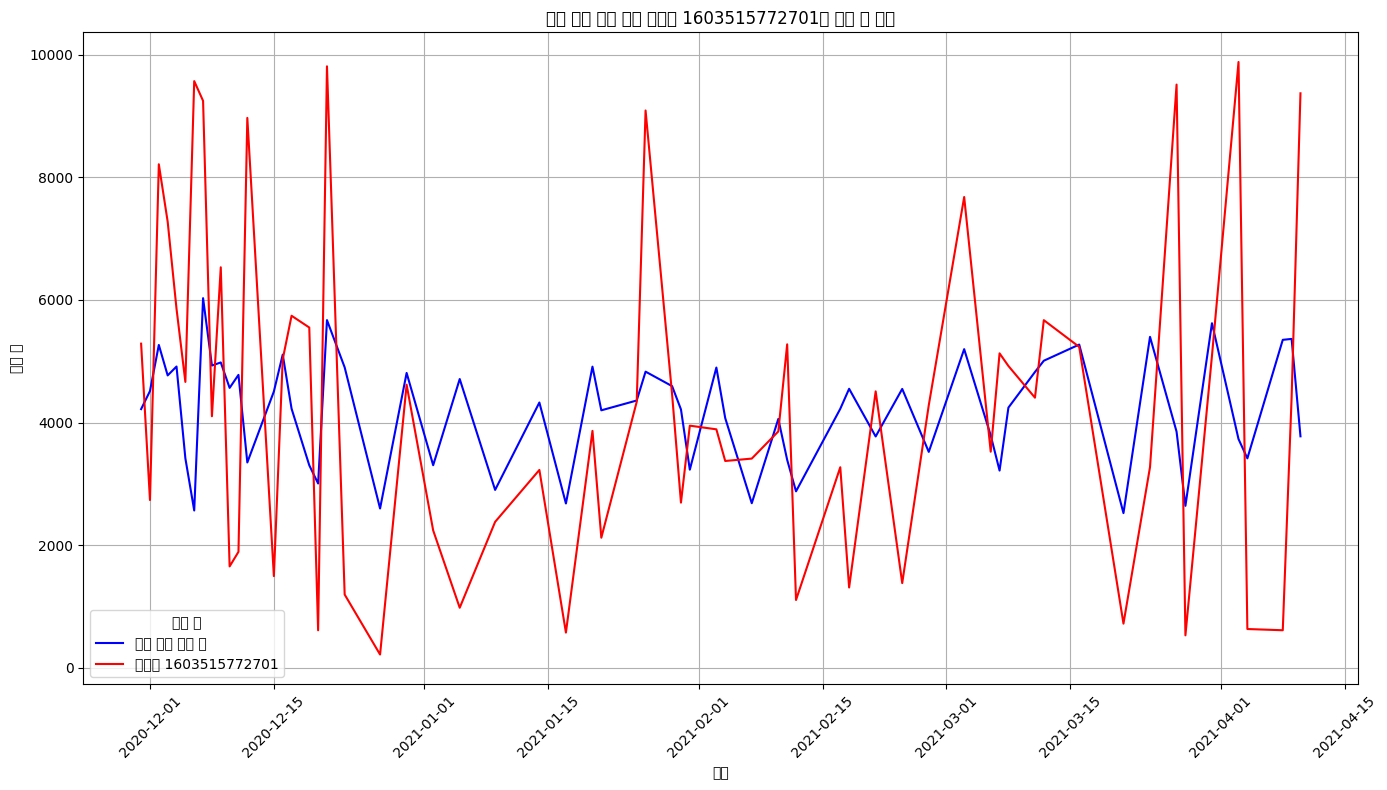

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# 데이터 로드
user_health_data = health_data

user_health_data['DT'] = pd.to_datetime(user_health_data['DT'])

# 사용자 데이터 필터링 및 날짜 추출
random_user_id = user_health_data['USER_ID'].sample(1).values[0]
user_daily_steps = user_health_data[user_health_data['USER_ID'] == random_user_id]

# 일일 평균 걸음 수 데이터 생성 (여기서는 이미 존재한다고 가정)
daily_avg_steps = user_health_data.groupby('DT').agg({'TOTAL_WALK_CNT': 'mean'}).reset_index()

# 사용자 데이터에서 날짜 추출
user_dates = user_daily_steps['DT'].dt.date

# 평균 데이터에서 해당 날짜만 필터링
filtered_avg_steps = daily_avg_steps[daily_avg_steps['DT'].dt.date.isin(user_dates)]

plt.figure(figsize=(14, 8))

# 일일 평균 걸음 수 점 그래프
sns.lineplot(data=filtered_avg_steps, x='DT', y='TOTAL_WALK_CNT', label='일일 평균 걸음 수', color='blue')

# 선택된 사용자 걸음 수 그래프
sns.lineplot(data=user_daily_steps, x='DT', y='TOTAL_WALK_CNT', label=f'사용자 {random_user_id}', color='red')

# 그래프 꾸미기
plt.title(f'일일 평균 걸음 수와 사용자 {random_user_id}의 걸음 수 비교')
plt.xlabel('날짜')
plt.ylabel('걸음 수')
plt.legend(title='걸음 수')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.show()


<ipython-input-82-56080d29c16b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_health_data['DT'] = pd.to_datetime(user_health_data['DT'])
<ipython-input-82-56080d29c16b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_data['Weekday'] = user_data['DT'].dt.day_name()
<ipython-input-82-56080d29c16b>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

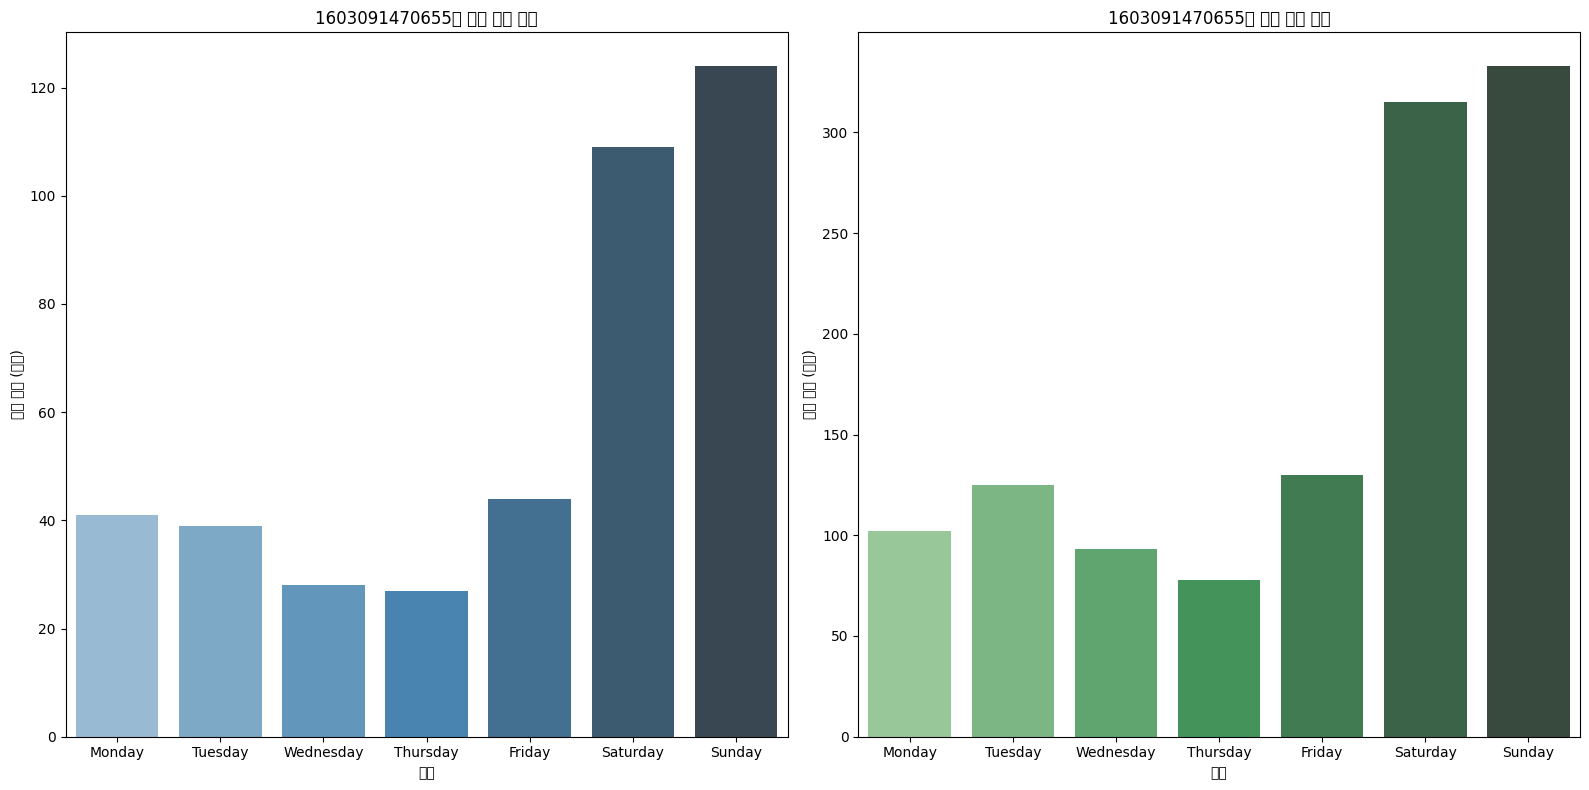

In [ ]:
# 데이터 로드
user_health_data['DT'] = pd.to_datetime(user_health_data['DT'])

# 랜덤 사용자 선택
random_user_id = user_health_data['USER_ID'].sample(1).values[0]
user_data = user_health_data[user_health_data['USER_ID'] == random_user_id]

# 요일 추출
user_data['Weekday'] = user_data['DT'].dt.day_name()

# 주간 운동 시간 계산
weekly_exercise = user_data.groupby('Weekday')['EXC_HOURS'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()
weekly_exercise.columns = ['Weekday', 'Total Exercise Hours']

# 주간 수면 시간 계산
weekly_sleep = user_data.groupby('Weekday')['SLEEP_HOURS'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()
weekly_sleep.columns = ['Weekday', 'Total Sleep Hours']

plt.figure(figsize=(16, 8))

# 운동 시간 막대 그래프
plt.subplot(1, 2, 1)
sns.barplot(data=weekly_exercise, x='Weekday', y='Total Exercise Hours', palette='Blues_d')
plt.title(f'{random_user_id}의 주간 운동 시간')
plt.xlabel('요일')
plt.ylabel('운동 시간 (시간)')

# 수면 시간 막대 그래프
plt.subplot(1, 2, 2)
sns.barplot(data=weekly_sleep, x='Weekday', y='Total Sleep Hours', palette='Greens_d')
plt.title(f'{random_user_id}의 주간 수면 시간')
plt.xlabel('요일')
plt.ylabel('수면 시간 (시간)')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from current fon

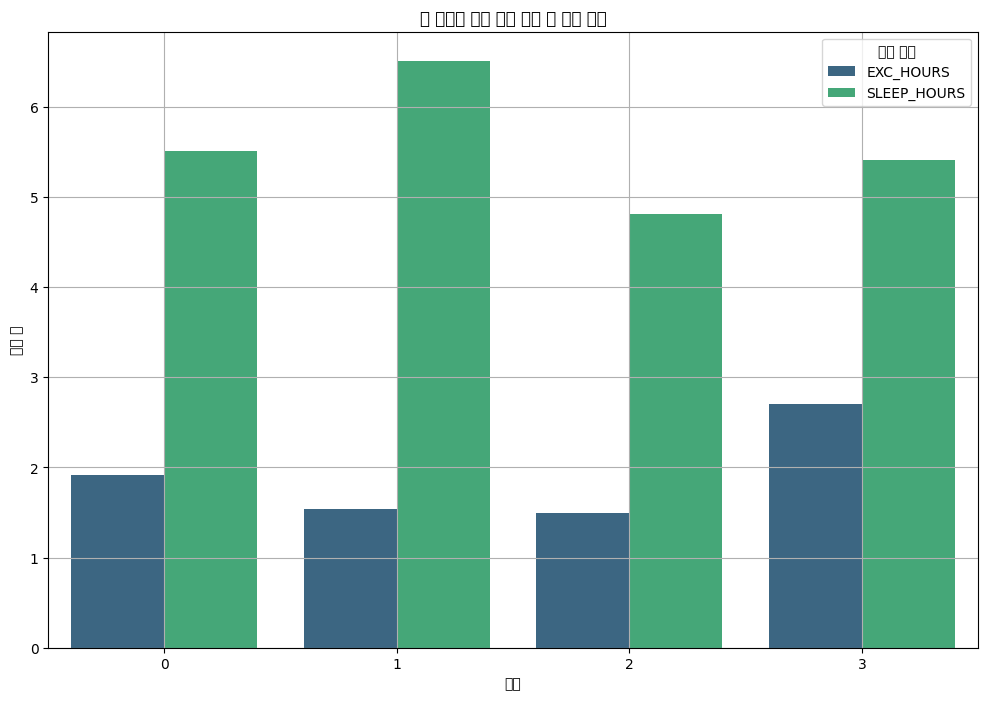

In [ ]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 결측치 및 이상치 처리
user_health_data = user_health_data[(user_health_data['TOTAL_WALK_CNT'] > 0) &
                                    (user_health_data['EXC_HOURS'] >= 0) &
                                    (user_health_data['SLEEP_HOURS'] >= 0)]

# 피처 엔지니어링
user_health_data['Weekday'] = user_health_data['DT'].dt.dayofweek

# 주간 평균 계산
weekly_avg = user_health_data.groupby(['USER_ID', 'Weekday'])[['EXC_HOURS', 'SLEEP_HOURS']].mean().reset_index()

# 피처 스케일링 및 군집화
features = weekly_avg[['EXC_HOURS', 'SLEEP_HOURS']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=4, random_state=42)
weekly_avg['Cluster'] = kmeans.fit_predict(scaled_features)

# 군집의 평균 값 시각화
plt.figure(figsize=(12, 8))
cluster_means = weekly_avg.groupby('Cluster')[['EXC_HOURS', 'SLEEP_HOURS']].mean().reset_index()
cluster_means = cluster_means.melt(id_vars='Cluster', var_name='Activity', value_name='Hours')
sns.barplot(data=cluster_means, x='Cluster', y='Hours', hue='Activity', palette='viridis')
plt.title('각 군집의 평균 운동 시간 및 수면 시간')
plt.xlabel('군집')
plt.ylabel('평균 값')
plt.legend(title='측정 항목')
plt.grid(True)
plt.show()

점수 계산 방법

1.   걸음 수 점수
30
×
사용자의 평균 걸음 수
전체 사용자 평균 걸음 수
걸음 수 점수=30×
전체 사용자 평균 걸음 수
사용자의 평균 걸음 수
​

2.   운동 시간 점수
30
×
사용자의 평균 운동 시간
전체 사용자 평균 운동 시간
운동 시간 점수=30×
전체 사용자 평균 운동 시간
사용자의 평균 운동 시간
​

3.   수면 시간 점수
40
×
사용자의 평균 수면 시간
전체 사용자 평균 수면 시간
수면 시간 점수=40×
전체 사용자 평균 수면 시간
사용자의 평균 수면 시간
​


최종 건강 점수:

건강 점수
=
걸음 수 점수
+
운동 시간 점수
+
수면 시간 점수

In [ ]:
import pandas as pd

# 전체 사용자 평균 계산 (걸음 수, 운동 시간, 수면 시간)
avg_walk_cnt = user_health_data['TOTAL_WALK_CNT'].mean()
avg_exc_hours = user_health_data['EXC_HOURS'].mean()
avg_sleep_hours = user_health_data['SLEEP_HOURS'].mean()

# 각 날의 건강 점수 계산
user_health_data['walk_score'] = 30 * (user_health_data['TOTAL_WALK_CNT'] / avg_walk_cnt)
user_health_data['exc_score'] = 30 * (user_health_data['EXC_HOURS'] / avg_exc_hours)
user_health_data['sleep_score'] = 40 * (user_health_data['SLEEP_HOURS'] / avg_sleep_hours)

# 각 점수가 최대 30, 30, 40을 넘지 않도록 제한하고 반올림하여 정수로 변환
user_health_data['walk_score'] = user_health_data['walk_score'].clip(upper=30).round().astype(int)
user_health_data['exc_score'] = user_health_data['exc_score'].clip(upper=30).round().astype(int)
user_health_data['sleep_score'] = user_health_data['sleep_score'].clip(upper=40).round().astype(int)

# 매일매일의 건강 점수 계산 (100점 만점) 후 반올림하여 정수로 변환
user_health_data['health_score'] = (user_health_data['walk_score'] + user_health_data['exc_score'] + user_health_data['sleep_score']).round().astype(int)

# 결과 확인
user_health_data


,USER_ID,DT,TOTAL_WALK_CNT,EXC_START_TIME,EXC_END_TIME,SLEEP_START_TIME,SLEEP_END_TIME,SLEEP_HOURS,EXC_HOURS,Weekday,walk_score,exc_score,sleep_score,health_score
1,1576547219647,2019-12-18,611,1700,1900,0600,1000,4,2,2,4,30,29,63
2,1576547219647,2019-12-19,1903,0500,0600,0900,1400,5,1,3,13,16,36,65
3,1576547219647,2019-12-20,602,0700,0800,0900,1700,8,1,4,4,16,40,60
5,1576547219647,2019-12-22,8415,1100,1400,0300,0700,4,3,6,30,30,29,89
6,1576547219647,2019-12-23,7168,0400,0600,1300,1700,4,2,0,30,30,29,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33616,1698208505811,2024-01-02,3500,1100,1300,1200,1900,7,2,1,23,30,40,93
33617,1698208505811,2024-01-03,4610,0400,0700,1000,1600,6,3,2,30,30,40,100
33618,1698208505811,2024-01-04,545,1500,1700,1900,0100,6,2,3,4,30,40,74
33619,1698208505811,2024-01-05,3915,0400,0700,0900,1600,7,3,4,26,30,40,96


건강 점수 예측


In [ ]:
user_health_data['DT'] = pd.to_datetime(user_health_data['DT'])
excluded_user_id = 1698208469161

train_data = user_health_data[user_health_data['USER_ID'] != excluded_user_id]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 모델 초기화
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=0),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=0)
}

# 데이터 전처리 및 피처 엔지니어링
features = ['SLEEP_HOURS', 'EXC_HOURS', 'Weekday', 'walk_score', 'exc_score', 'sleep_score']
train_data['DT'] = pd.to_datetime(train_data['DT'])

# 전체 데이터를 학습 데이터와 테스트 데이터로 분할
X = train_data[features]
y = train_data['health_score']

# 80% 데이터로 학습, 20% 데이터로 테스트
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 모델 학습 및 평가
best_model = None
best_r2 = -np.inf
model_performance = {}

for model_name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 성능 평가
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    model_performance[model_name] = {'R²': r2, 'MAE': mae, 'MSE': mse}

    if r2 > best_r2:
        best_r2 = r2
        best_model = model

print(f"Best model based on R² score: {best_model.__class__.__name__}\n")

Best model based on R² score: LinearRegression



<ipython-input-96-b7a9ac9ad705>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_data['DT'] = pd.to_datetime(user_data['DT'])


R²: 0.42
MAE: 5.66
MSE: 64.52


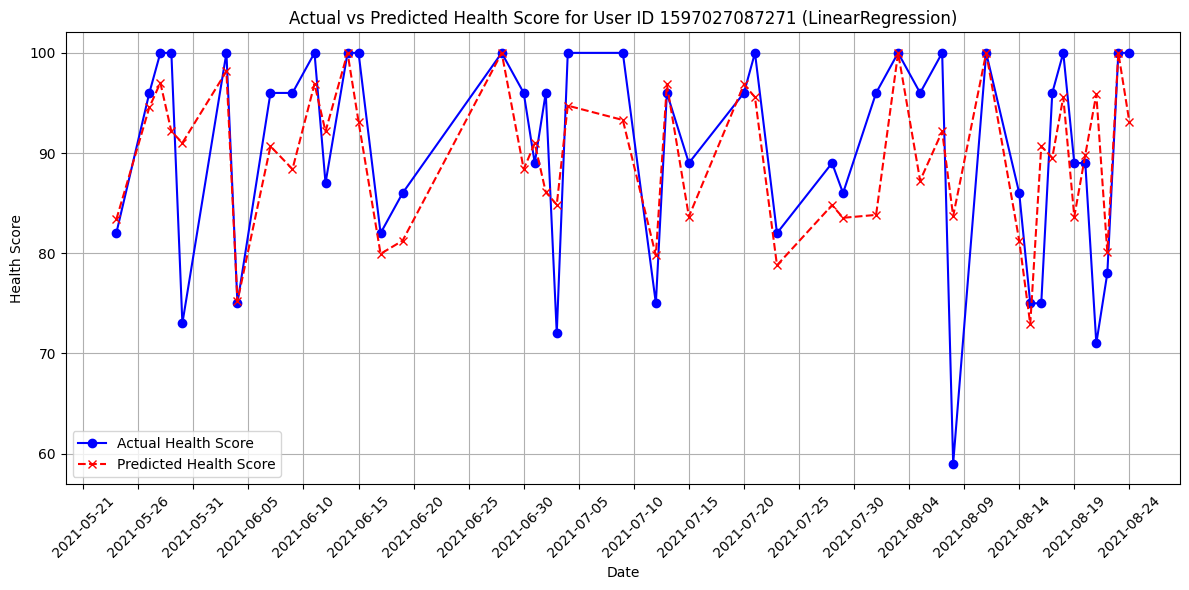

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예제 데이터프레임 로딩 (파일에서 읽어오는 경우)
# user_health_data = pd.read_csv('path_to_your_data.csv')

# 랜덤 사용자 ID 선택
test_user_id = '1597027087271'
user_data = user_health_data[user_health_data['USER_ID'] == test_user_id]

# 날짜 형식 변환
user_data['DT'] = pd.to_datetime(user_data['DT'])

# 데이터 분할
cutoff_date = user_data['DT'].quantile(0.8)
train_data = user_data[user_data['DT'] < cutoff_date]
test_data = user_data[user_data['DT'] >= cutoff_date]

# 피처와 타겟 설정
features = ['SLEEP_HOURS', 'EXC_HOURS', 'Weekday']  # 사용할 피처
X_user_train = train_data[features]
y_user_train = train_data['health_score']
X_user_test = test_data[features]
y_user_test = test_data['health_score']
test_dates = test_data['DT']

# 모델 학습 및 예측
best_model.fit(X_user_train, y_user_train)
y_user_pred = best_model.predict(X_user_test)
y_user_pred = np.clip(y_user_pred, a_min=None, a_max=100)

# 정확도 확인
print(f"R²: {r2_score(y_user_test, y_user_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_user_test, y_user_pred):.2f}")
print(f"MSE: {mean_squared_error(y_user_test, y_user_pred):.2f}")

# 예측 결과와 실제 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_user_test, marker='o', linestyle='-', label='Actual Health Score', color='blue')
plt.plot(test_dates, y_user_pred, marker='x', linestyle='--', label='Predicted Health Score', color='red')
plt.xlabel('Date')
plt.ylabel('Health Score')
plt.title(f'Actual vs Predicted Health Score for User ID {test_user_id} ({best_model.__class__.__name__})')
plt.legend()
plt.xticks(rotation=45)

# 날짜 포맷과 간격 조정
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))  # Show every 5th day
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 사용자 ID를 랜덤으로 선택
random_user_id = np.random.choice(user_health_data['USER_ID'].unique())
user_data = user_health_data[user_health_data['USER_ID'] == random_user_id]

# 날짜 처리 및 요일 추가
user_data['DT'] = pd.to_datetime(user_data['DT'])
user_data['weekday'] = user_data['DT'].dt.weekday

# 특성 및 타겟 설정
X = user_data[['SLEEP_HOURS', 'EXC_HOURS', 'weekday']]
y = user_data['TOTAL_WALK_CNT']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


<ipython-input-102-7fbf7bf79900>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_data['DT'] = pd.to_datetime(user_data['DT'])
<ipython-input-102-7fbf7bf79900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_data['weekday'] = user_data['DT'].dt.weekday


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 모델 학습
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 예측
y_pred_lr = lr_model.predict(X_test)

# 모델 성능 평가
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))



Linear Regression R²: -0.03831505191013451
Linear Regression MAE: 1395.5122059158005
Linear Regression MSE: 5800677.8868240705


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 모델 학습
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# 예측
y_pred_rf = rf_model.predict(X_test)

# 모델 성능 평가
print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))


Random Forest R²: -0.09903419640251343
Random Forest MAE: 1614.76051984127
Random Forest MSE: 6139893.039407934


In [ ]:
# 결측치 확인 및 처리
user_health_data = user_health_data.dropna()  # 결측치 제거 (예시, 필요에 따라 대체)

# 새로운 특성 추가 (예: 최근 7일 평균)
user_health_data['7day_avg_walk'] = user_health_data['TOTAL_WALK_CNT'].rolling(window=7).mean().shift(1)
user_health_data['7day_avg_sleep'] = user_health_data['SLEEP_HOURS'].rolling(window=7).mean().shift(1)
user_health_data['7day_avg_exc'] = user_health_data['EXC_HOURS'].rolling(window=7).mean().shift(1)

# 요일 및 월간 데이터 추가
user_health_data['month'] = user_health_data['DT'].dt.month
user_health_data['day_of_month'] = user_health_data['DT'].dt.day

# 데이터 전처리
user_health_data = user_health_data.dropna()


Gradient Boosting R²: 0.25688915020669223
Gradient Boosting MAE: 1933.877343674988
Gradient Boosting MSE: 5736005.940815423


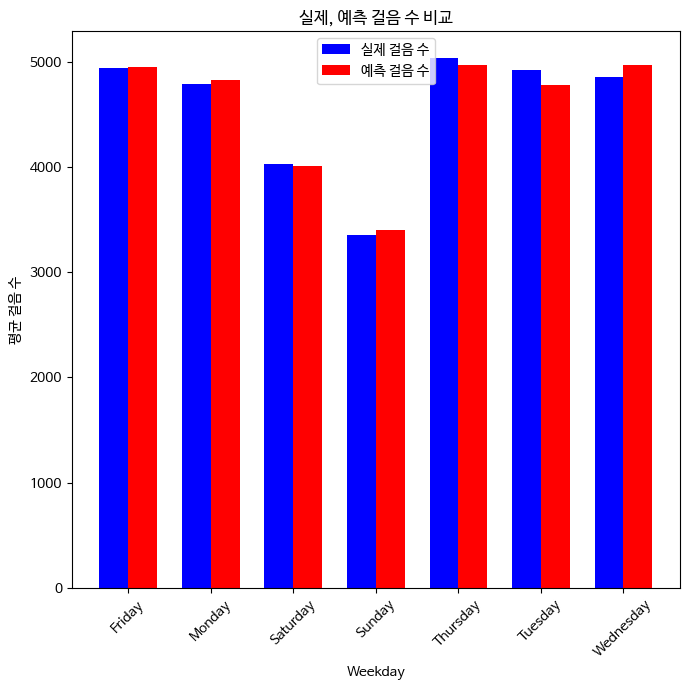

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 데이터 준비
X = user_health_data[['SLEEP_HOURS', 'EXC_HOURS', '7day_avg_walk', '7day_avg_sleep', '7day_avg_exc', 'Weekday', 'month', 'day_of_month']]
y = user_health_data['TOTAL_WALK_CNT']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 모델 훈련 (Gradient Boosting Regressor 사용)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=0)
gb_model.fit(X_train, y_train)

# 예측
y_pred_gb = gb_model.predict(X_test)

# 모델 성능 평가
print("Gradient Boosting R²:", r2_score(y_test, y_pred_gb))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, y_pred_gb))
print("Gradient Boosting MSE:", mean_squared_error(y_test, y_pred_gb))

# 테스트 데이터와 예측 결과 결합
test_data = X_test.copy()
test_data['Actual_Walk_Count'] = y_test
test_data['Predicted_Walk_Count'] = y_pred_gb

# 시각화를 위한 요일별 집계
weekday_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
test_data['weekday_name'] = test_data['Weekday'].map(weekday_names)

# 요일별 집계
actual_by_weekday = test_data.groupby('weekday_name').agg({'Actual_Walk_Count': 'mean', 'Predicted_Walk_Count': 'mean'}).reset_index()

# 시각화
plt.figure(figsize=(7, 7))
bar_width = 0.35
index = np.arange(len(actual_by_weekday))

# 실제 걸음 수
plt.bar(index - bar_width/2, actual_by_weekday['Actual_Walk_Count'], bar_width, label='실제 걸음 수', color='blue')

# 예측 걸음 수
plt.bar(index + bar_width/2, actual_by_weekday['Predicted_Walk_Count'], bar_width, label='예측 걸음 수', color='red')

plt.xlabel('Weekday')
plt.ylabel('평균 걸음 수')
plt.title('실제, 예측 걸음 수 비교')
plt.xticks(index, actual_by_weekday['weekday_name'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

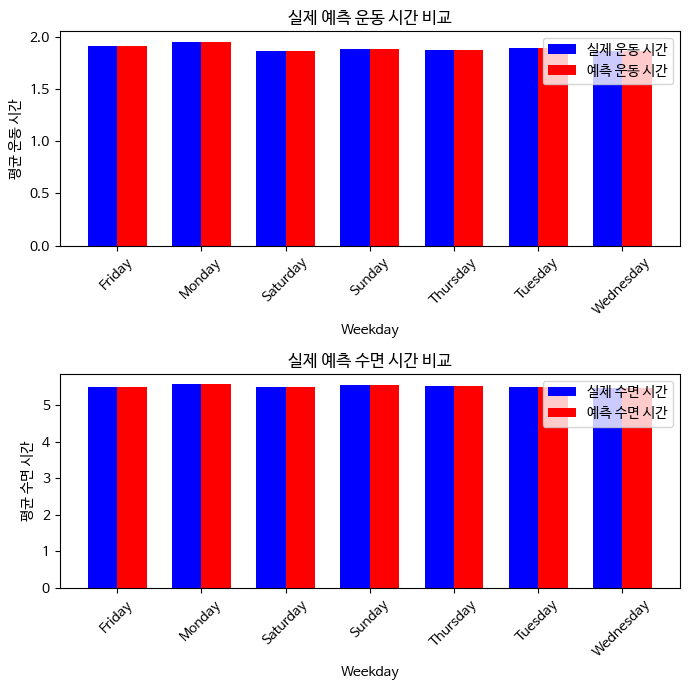

In [ ]:
# 운동 시간과 수면 시간 시각화 (여기서는 동일한 방식으로 예시로 추가)
fig, axs = plt.subplots(2, 1, figsize=(7, 7))

# 운동 시간 시각화
actual_by_weekday['Actual_Exc_Hours'] = test_data.groupby('weekday_name')['EXC_HOURS'].mean().values
actual_by_weekday['Predicted_Exc_Hours'] = test_data.groupby('weekday_name')['EXC_HOURS'].mean().values  # Placeholder for actual prediction

axs[0].bar(index - bar_width/2, actual_by_weekday['Actual_Exc_Hours'], bar_width, label='실제 운동 시간', color='blue')
axs[0].bar(index + bar_width/2, actual_by_weekday['Predicted_Exc_Hours'], bar_width, label='예측 운동 시간', color='red')
axs[0].set_xlabel('Weekday')
axs[0].set_ylabel('평균 운동 시간')
axs[0].set_title('실제 예측 운동 시간 비교')
axs[0].set_xticks(index)
axs[0].set_xticklabels(actual_by_weekday['weekday_name'], rotation=45)
axs[0].legend()

# 수면 시간 시각화
actual_by_weekday['Actual_Sleep_Hours'] = test_data.groupby('weekday_name')['SLEEP_HOURS'].mean().values
actual_by_weekday['Predicted_Sleep_Hours'] = test_data.groupby('weekday_name')['SLEEP_HOURS'].mean().values  # Placeholder for actual prediction

axs[1].bar(index - bar_width/2, actual_by_weekday['Actual_Sleep_Hours'], bar_width, label='실제 수면 시간', color='blue')
axs[1].bar(index + bar_width/2, actual_by_weekday['Predicted_Sleep_Hours'], bar_width, label='예측 수면 시간', color='red')
axs[1].set_xlabel('Weekday')
axs[1].set_ylabel('평균 수면 시간')
axs[1].set_title('실제 예측 수면 시간 비교')
axs[1].set_xticks(index)
axs[1].set_xticklabels(actual_by_weekday['weekday_name'], rotation=45)
axs[1].legend()

plt.tight_layout()
plt.show()


Selected USER_ID: 1586419180966
             DT  health_score  Predicted_Health_Score
4484 2021-11-24           100               89.630636
4485 2021-11-25           100               92.975417
4486 2021-11-26           100               96.720022
4487 2021-11-27            82               74.822791
4488 2021-11-28            86               77.420286
4492 2021-12-02           100               97.225260
4493 2021-12-03            86               83.801509
4494 2021-12-04            75               72.774802
4495 2021-12-05           100               94.956286
4496 2021-12-06           100               98.179345
4498 2021-12-08           100               98.276975
4499 2021-12-09           100               98.354467
4500 2021-12-10           100               99.192567
4501 2021-12-11            68               81.445959
4502 2021-12-12            96               88.646155
4503 2021-12-13           100               98.076308
4504 2021-12-14            86               84.033

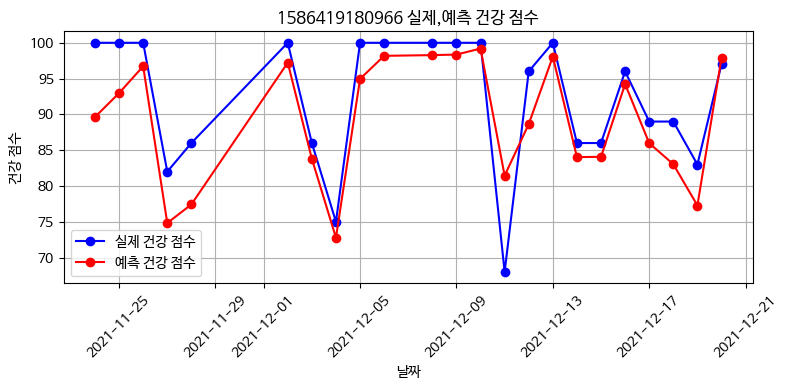

In [ ]:
# 랜덤 사용자 선택
random_user_id = random.choice(user_health_data['USER_ID'].unique())
print(f"Selected USER_ID: {random_user_id}")

# 선택된 사용자의 데이터 추출
user_data = user_health_data[user_health_data['USER_ID'] == random_user_id].copy()

# 데이터 준비
X = user_health_data[['SLEEP_HOURS', 'EXC_HOURS', '7day_avg_walk', '7day_avg_sleep', '7day_avg_exc', 'Weekday', 'month', 'day_of_month']]
y = user_health_data['health_score']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 모델 훈련
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=0)
gb_model.fit(X_train, y_train)

# 예측
user_data['Predicted_Health_Score'] = gb_model.predict(user_data[['SLEEP_HOURS', 'EXC_HOURS', '7day_avg_walk', '7day_avg_sleep', '7day_avg_exc', 'Weekday', 'month', 'day_of_month']])

# 이 사람의 실제 데이터
print(user_data[['DT', 'health_score', 'Predicted_Health_Score']])

# 시각화
plt.figure(figsize=(8, 4))

# 실제 건강 점수
plt.plot(user_data['DT'], user_data['health_score'], marker='o', label='실제 건강 점수', color='blue')

# 예측된 건강 점수
plt.plot(user_data['DT'], user_data['Predicted_Health_Score'], marker='o',label='예측 건강 점수', color='red')

# 그래프 꾸미기
plt.title(f'{random_user_id} 실제,예측 건강 점수')
plt.xlabel('날짜')
plt.ylabel('건강 점수')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.show()

1. MSE : 평균 제곱 오차
  수치가 작을수록 정확성이 높다.

2. MAE : 평균 절대 오차
  회귀지표

In [ ]:
!pip install flask_ngrok
!pip install pyngrok==4.1.1

  Preparing metadata (setup.py) ... done
  Created wheel for pyngrok: filename=pyngrok-4.1.1-py3-none-any.whl size=15965 sha256=a1fed886c04e1a3abe236879d00d241b29b1853c456e2ff6f9ec3edec6349fae
  Stored in directory: /root/.cache/pip/wheels/4c/7c/4c/632fba2ea8e88d8890102eb07bc922e1ca8fa14db5902c91a8
Successfully built pyngrok


In [ ]:
!pip install pyngrok

In [ ]:
!ngrok authtoken '2kjU4B18iHDQ18Vr6wwFkQILeFr_7MrmQj9JxPBurYQ5abxhT'

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!ngrok --version
!pip install --upgrade pyngrok

ngrok version 3.14.0
pyngrok version 7.2.0


In [ ]:
from pyngrok import ngrok

# Ngrok 설정 (http 프로토콜 명시)
public_url = ngrok.connect(5000, "http")
print(f"Public URL: {public_url}")


Public URL: NgrokTunnel: "https://35ec-35-224-87-15.ngrok-free.app" -> "http://localhost:5000"


In [ ]:
from flask import Flask, render_template
from pyngrok import ngrok

app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html')

if __name__ == "__main__":
    # Ngrok 설정 (http 프로토콜 명시)
    public_url = ngrok.connect(5000, "http")
    print(f"Public URL: {public_url}")

    # Flask 서버 실행
    app.run(host='0.0.0.0', port=5000)


Public URL: NgrokTunnel: "https://7f1d-35-224-87-15.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
ERROR:__main__:Exception on / [GET]
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/flask/app.py", line 2529, in wsgi_app
    response = self.full_dispatch_request()
  File "/usr/local/lib/python3.10/dist-packages/flask/app.py", line 1825, in full_dispatch_request
    rv = self.handle_user_exception(e)
  File "/usr/local/lib/python3.10/dist-packages/flask/app.py", line 1823, in full_dispatch_request
    rv = self.dispatch_request()
  File "/usr/local/lib/python3.10/dist-packages/flask/app.py", line 1799, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)
  File "<ipython-input-14-19d0e787be01>", line 8, in index
    return render_t